<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment-Week-1-/blob/main/assignment%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [32]:
from google.colab import files
import cv2
import numpy as np

images = {}

while True:
    print("\n Upload an image (or click Cancel to stop):")
    uploaded = files.upload()

    if len(uploaded) == 0:
        break

    for filename in uploaded.keys():
        img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)
        images[filename] = img

    print(f"Total images uploaded: {len(images)}")

print("\nFinal number of images:", len(images))


⬆️ Upload an image (or click Cancel to stop):


Saving alexander-lunyov-Hdzn_gIdh1o-unsplash.jpg to alexander-lunyov-Hdzn_gIdh1o-unsplash (3).jpg
Total images uploaded: 1

⬆️ Upload an image (or click Cancel to stop):


Saving evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg to evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg
Total images uploaded: 2

⬆️ Upload an image (or click Cancel to stop):


Saving kalen-emsley-Bkci_8qcdvQ-unsplash.jpg to kalen-emsley-Bkci_8qcdvQ-unsplash.jpg
Total images uploaded: 3

⬆️ Upload an image (or click Cancel to stop):


Saving stefan-stefancik-QXevDflbl8A-unsplash.jpg to stefan-stefancik-QXevDflbl8A-unsplash.jpg
Total images uploaded: 4

⬆️ Upload an image (or click Cancel to stop):



Final number of images: 4


In [33]:
print(images.keys())

dict_keys(['alexander-lunyov-Hdzn_gIdh1o-unsplash (3).jpg', 'evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg', 'kalen-emsley-Bkci_8qcdvQ-unsplash.jpg', 'stefan-stefancik-QXevDflbl8A-unsplash.jpg'])


In [34]:
for name, img in images.items():
    print(f"\n--- Statistics for {name} ---")
    print("Shape:", img.shape)
    print("Data type:", img.dtype)
    print("Min pixel:", img.min())
    print("Max pixel:", img.max())
    print("Mean pixel:", img.mean())



--- Statistics for alexander-lunyov-Hdzn_gIdh1o-unsplash (3).jpg ---
Shape: (960, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean pixel: 105.6062158203125

--- Statistics for evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg ---
Shape: (427, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean pixel: 92.17393881733021

--- Statistics for kalen-emsley-Bkci_8qcdvQ-unsplash.jpg ---
Shape: (427, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean pixel: 102.19600287861046

--- Statistics for stefan-stefancik-QXevDflbl8A-unsplash.jpg ---
Shape: (959, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 243
Mean pixel: 83.69519410410149


In [35]:
# --- Define kernels --
# Box Blur
kernel_blur = np.ones((5, 5), np.float32) / 25

# Sobel X
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Sobel Y
kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Laplacian
kernel_laplacian = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float32)

# Sharpen
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)


--- Processing alexander-lunyov-Hdzn_gIdh1o-unsplash (3).jpg ---


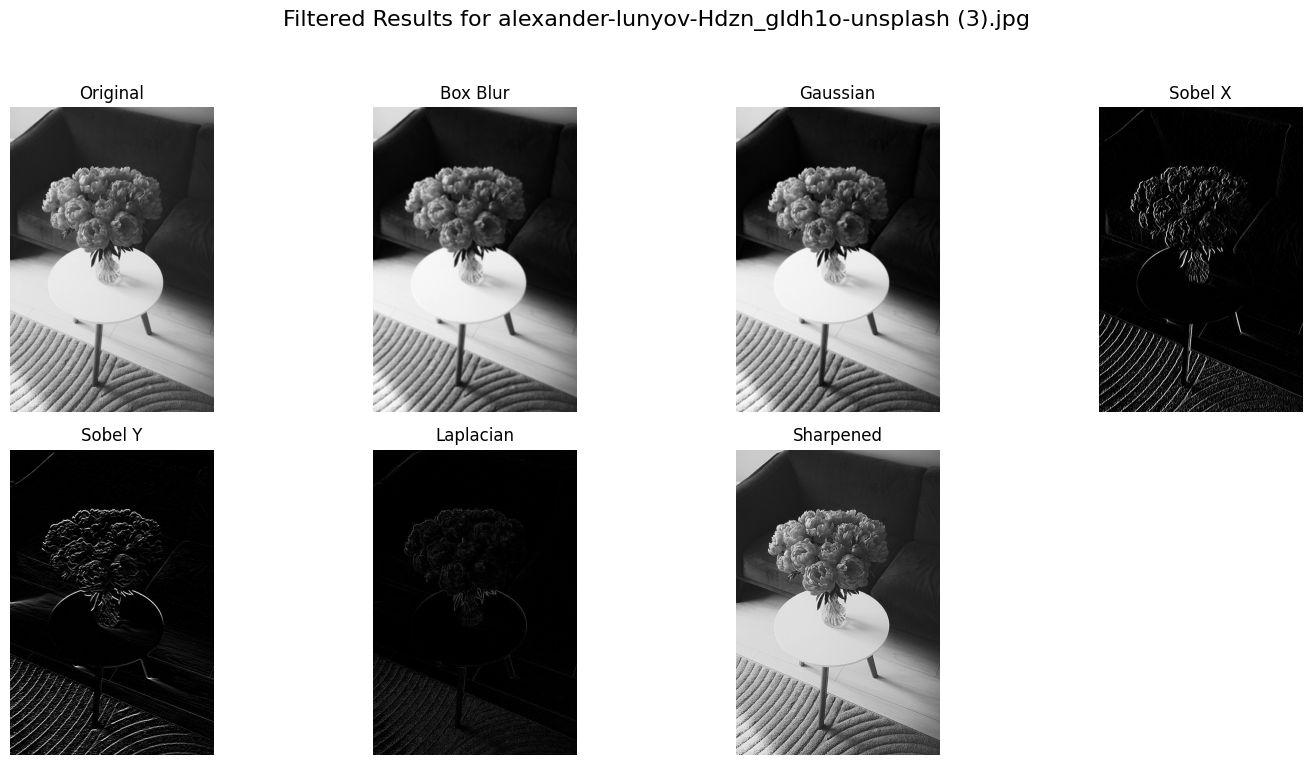


--- Processing evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg ---


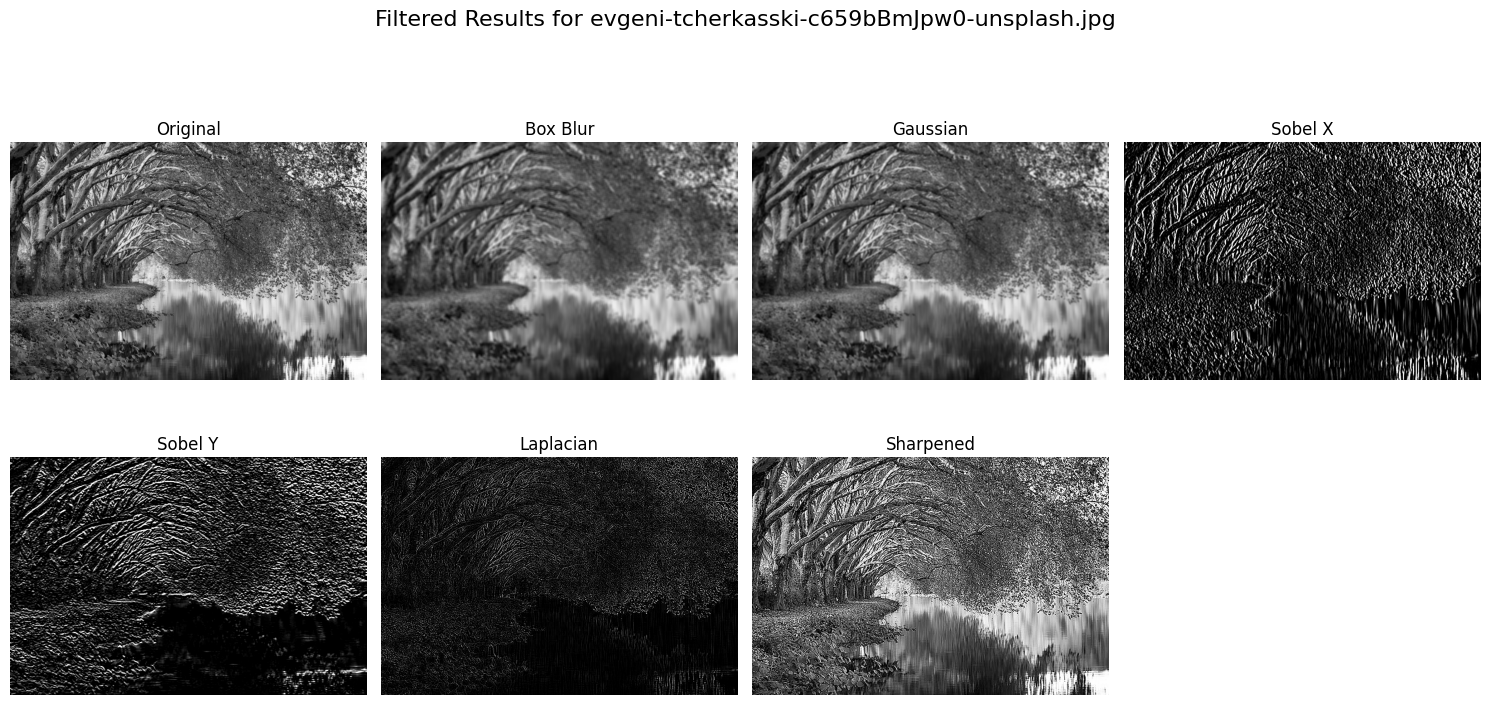


--- Processing kalen-emsley-Bkci_8qcdvQ-unsplash.jpg ---


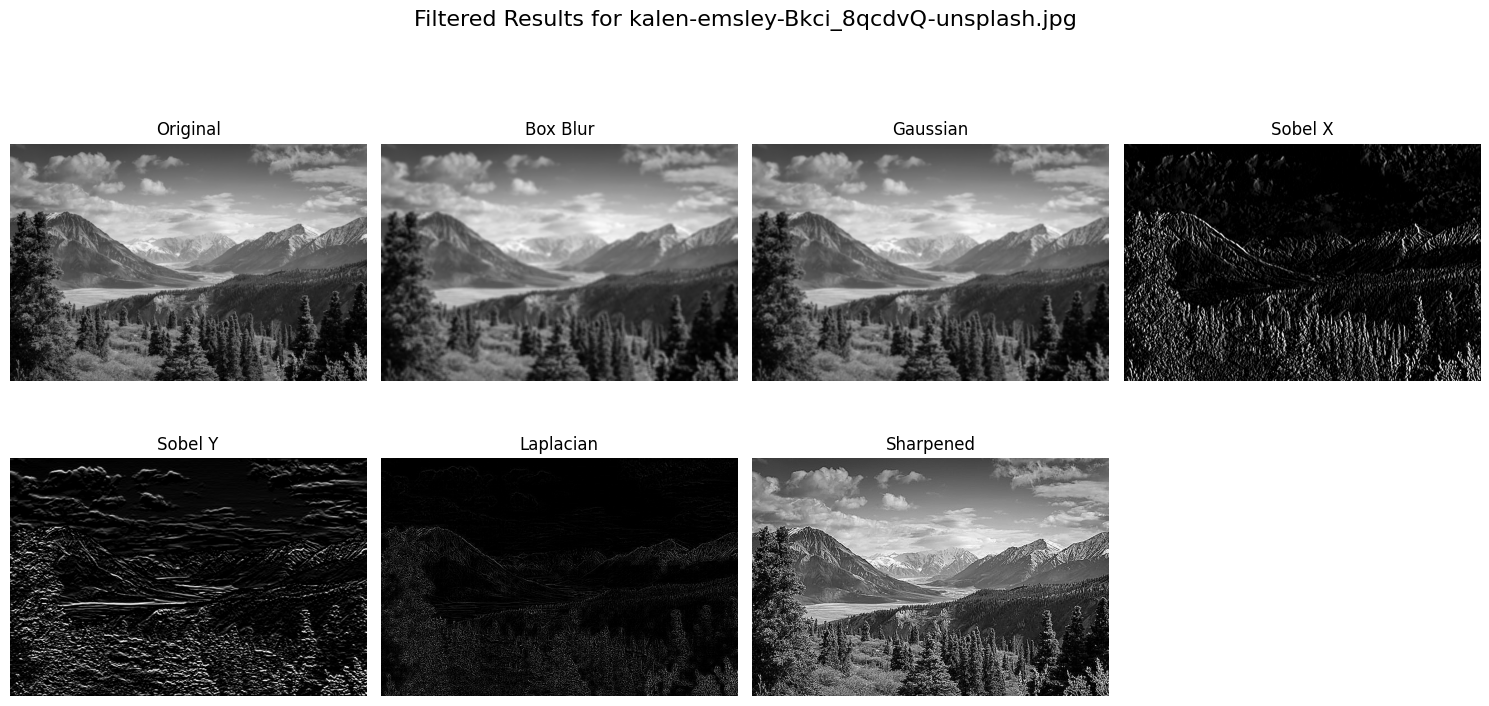


--- Processing stefan-stefancik-QXevDflbl8A-unsplash.jpg ---


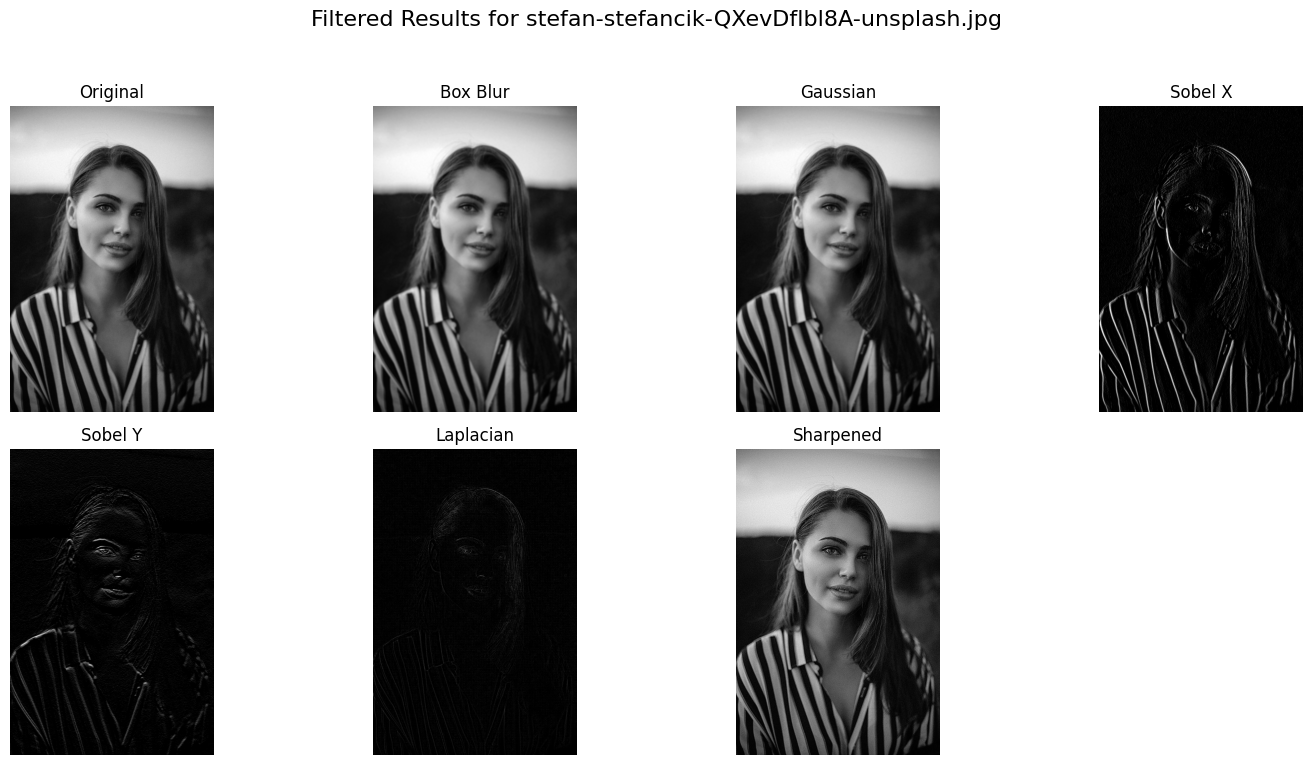

In [36]:
titles = ['Original', 'Box Blur', 'Gaussian', 'Sobel X', 'Sobel Y', 'Laplacian', 'Sharpened']

for name, img in images.items():
    print(f"\n--- Processing {name} ---")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply filters
    blurred    = cv2.filter2D(gray, -1, kernel_blur)
    gaussian   = cv2.GaussianBlur(gray, (5, 5), 0)
    edge_x     = cv2.filter2D(gray, -1, kernel_sobel_x)
    edge_y     = cv2.filter2D(gray, -1, kernel_sobel_y)
    laplacian  = cv2.filter2D(gray, -1, kernel_laplacian)
    sharpened  = cv2.filter2D(gray, -1, kernel_sharpen)

    images_to_display = [
        gray,
        blurred,
        gaussian,
        np.abs(edge_x).astype(np.uint8),
        np.abs(edge_y).astype(np.uint8),
        np.abs(laplacian).astype(np.uint8),
        sharpened
    ]

    # Display
    plt.figure(figsize=(15, 8))
    plt.suptitle(f'Filtered Results for {name}', fontsize=16)

    for i, (t, im) in enumerate(zip(titles, images_to_display)):
        plt.subplot(2, 4, i+1)
        plt.imshow(im, cmap='gray')
        plt.title(t)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [37]:
print("\n Saving filtered images...")

for name, img in images.items():
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    cv2.imwrite(f"{name}_blur.png", cv2.filter2D(gray, -1, kernel_blur))
    cv2.imwrite(f"{name}_gaussian.png", cv2.GaussianBlur(gray, (5, 5), 0))
    cv2.imwrite(f"{name}_sobelx.png", cv2.filter2D(gray, -1, kernel_sobel_x))
    cv2.imwrite(f"{name}_sobely.png", cv2.filter2D(gray, -1, kernel_sobel_y))
    cv2.imwrite(f"{name}_laplacian.png", cv2.filter2D(gray, -1, kernel_laplacian))
    cv2.imwrite(f"{name}_sharpen.png", cv2.filter2D(gray, -1, kernel_sharpen))

print("Done! Images saved.")


 Saving filtered images...
Done! Images saved.
